In [ ]:
import pandas as pd
import numpy as np

In [ ]:
orders = pd.read_excel("/content/sample_superstore.xlsm", sheet_name="sample_-_superstore")
returns = pd.read_excel("/content/sample_superstore.xlsm", sheet_name="Returns")
people = pd.read_excel("/content/sample_superstore.xlsm", sheet_name="People")

In [ ]:
returns.head()

,Returned,Order ID
0,Yes,CA-2017-153822
1,Yes,CA-2017-129707
2,Yes,CA-2014-152345
3,Yes,CA-2015-156440
4,Yes,US-2017-155999


In [ ]:
people.head()

,Person,Region
0,Anna Andreadi,West
1,Chuck Magee,East
2,Kelly Williams,Central
3,Cassandra Brandow,South


In [ ]:
orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
orders.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,2017-05-04,2017-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [ ]:
orders.shape

(9994, 21)

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [ ]:
orders.isnull().sum()

print("Duplicate rows :", orders.duplicated().sum())
print("Duplicated order+product combos :", orders.duplicated(subset=["Order ID", "Product Name"]).sum())

Duplicate rows : 0
Duplicated order+product combos : 8


In [ ]:
#fix data types

#correct date columns
orders['Order Date'] = pd.to_datetime(orders['Order Date'])
orders['Ship Date'] = pd.to_datetime(orders['Ship Date'])
orders['Postal Code'] = orders['Postal Code'].astype(str).str.zfill(5)


In [ ]:
for col in ["Ship Mode", "Segment", "Region", "Category"]:
    print(col, "->", sorted(orders[col].unique()))

Ship Mode -> ['First Class', 'Same Day', 'Second Class', 'Standard Class']
Segment -> ['Consumer', 'Corporate', 'Home Office']
Region -> ['Central', 'East', 'South', 'West']
Category -> ['Furniture', 'Office Supplies', 'Technology']


In [ ]:
orders.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,NaN,NaN,4,793,793,3,1,531,...,631,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,NaN,NaN,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,10035,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,NaN,NaN,5968,37,37,5191,9994,915,...,263,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
min,1.000000,NaN,2014-01-03 00:00:00,2014-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,2015-05-23 00:00:00,2015-05-27 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,2016-06-26 00:00:00,2016-06-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,2017-05-14 00:00:00,2017-05-18 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000
max,9994.000000,NaN,2017-12-30 00:00:00,2018-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
#check datatypes
orders.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [ ]:
#check missing values
orders.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
#change col name
orders.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
returns.columns

Index(['Returned', 'Order ID'], dtype='object')

In [ ]:
returns.columns = returns.columns.str.lower()
returns.columns = returns.columns.str.replace(" ","_")

In [ ]:
people.columns

Index(['Person', 'Region'], dtype='object')

In [ ]:
people.columns = people.columns.str.lower()
people.columns = people.columns.str.replace(" ","_")

In [ ]:
orders.columns = orders.columns.str.lower()

In [ ]:
orders.columns = orders.columns.str.replace(" ","_")

In [ ]:
orders.head(1)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136


In [ ]:
#Outliers

orders[["sales","quantity", "discount", "profit"]].describe()

orders.sort_values("profit").head(5)[["order_id", "category", "sub-category","discount","sales","profit"]]

#IQR check on sales

q1, q3 = orders["sales"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

print("Upper fence : ", round(upper_bound),2)
print("rows  above fence :",(orders["sales"] > upper_bound).sum(), "out of ", len(orders))


Upper fence :  499 2
rows  above fence : 1167 out of  9994


In [ ]:
#Merge Related Sheets


orders_full = orders.merge(returns, on="order_id", how="left")
orders_full = orders_full.merge(people, on="region", how="left")

orders_full["returned"] = orders_full["returned"].fillna("No")
orders_full = orders_full.rename(columns={"person":"Regional Manager"})

print(orders_full.shape)
orders_full[["order_id", "region","returned", "Regional Manager"]].head()



(9994, 23)


,order_id,region,returned,Regional Manager
0,CA-2016-152156,South,No,Cassandra Brandow
1,CA-2016-152156,South,No,Cassandra Brandow
2,CA-2016-138688,West,No,Anna Andreadi
3,US-2015-108966,South,No,Cassandra Brandow
4,US-2015-108966,South,No,Cassandra Brandow


Assert -- check that a condition is True. if its True, nothing happens and the code continues


False - It stops the program , with an error


Subset - which columns to look at,used inside functions like duplicated(), dropna(), and drop_duplicates().

In [ ]:
#Validate and save

assert orders_full.duplicated(subset="row_id").sum() == 0
assert orders_full["returned"].isin(["Yes", "No"]).all()

import os
os.makedirs("cleaned", exist_ok=True)
orders_full.to_csv("cleaned/orders_full.csv", index=False)
print("saved :" , orders_full.shape)



saved : (9994, 23)


In [ ]:
orders_full.head(1)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub-category,product_name,sales,quantity,discount,profit,returned,Regional Manager
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,No,Cassandra Brandow


In [ ]:
#check categorical column
orders['ship_mode'].unique()

array(['Second Class', 'Standard Class', 'First Class', 'Same Day'],
      dtype=object)

In [ ]:
orders['order_id'].unique()

array(['CA-2016-152156', 'CA-2016-138688', 'US-2015-108966', ...,
       'CA-2014-110422', 'CA-2017-121258', 'CA-2017-119914'], dtype=object)

In [ ]:

#check there must no ship_date before order_date
orders[orders['ship_date'] < orders['order_date']].shape[0]

0

In [ ]:
#checking for negative profit

orders[orders["profit"] < 0].shape[0]

1871

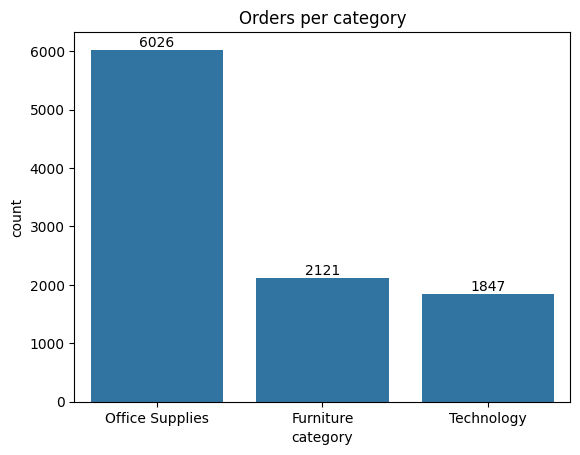

In [ ]:
#EDA

import matplotlib.pyplot as plt
import seaborn as sns

ax = sns.countplot(data=orders_full, x="category", order=orders_full["category"].value_counts().index)
ax.bar_label(ax.containers[0])
plt.title("Orders per category")
plt.show()


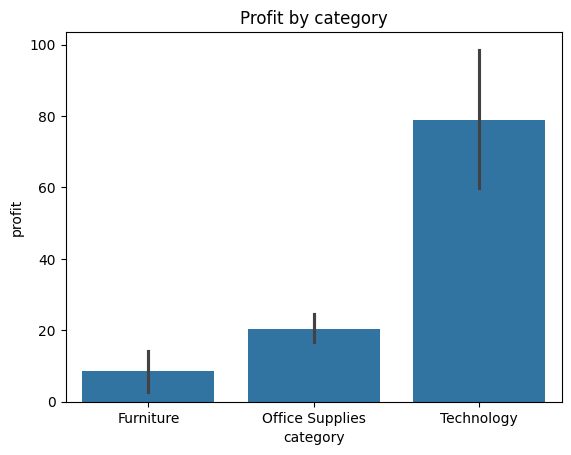

In [ ]:
#profit by category

sns.barplot(data=orders_full, x="category", y="profit")
plt.title("Profit by category")
plt.show()


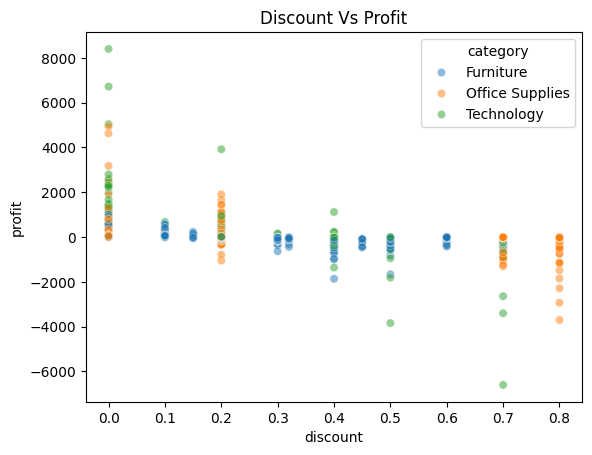

In [ ]:
#discount vs profit

sns.scatterplot(data=orders_full, x='discount', y="profit", hue="category", alpha=0.5)
plt.title("Discount Vs Profit")
plt.show()


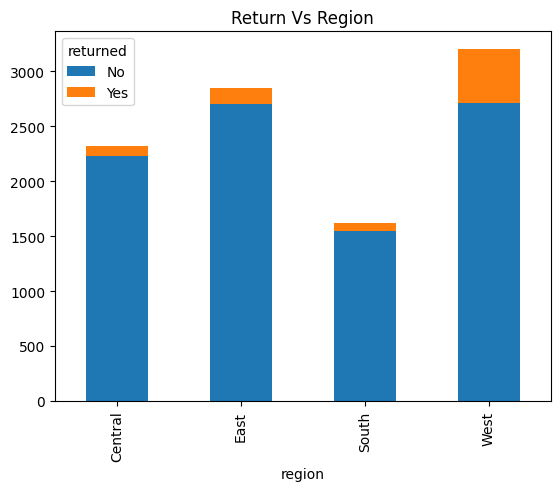

In [ ]:
#Region Vs Return

pd.crosstab(orders_full["region"], orders_full["returned"]).plot(kind="bar", stacked=True)
plt.title("Return Vs Region")
plt.show()


In [ ]:
from matplotlib.colors import Normalize
pd.crosstab(orders_full["region"], orders_full["returned"], normalize="index").round(3) * 100

returned,No,Yes
region,,
Central,96.0,4.0
East,94.8,5.2
South,95.7,4.3
West,84.7,15.3


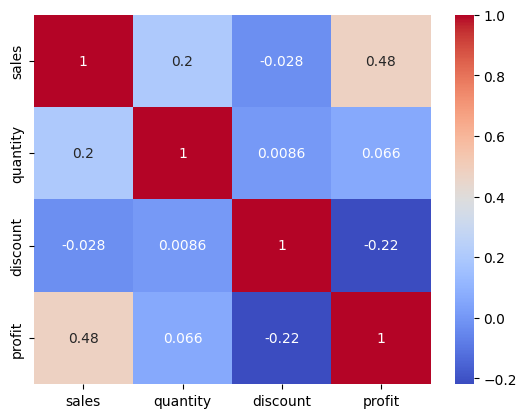

In [ ]:
#correlation

corr = orders_full[["sales", "quantity", "discount", "profit"]].corr()

plt.figure()

sns.heatmap(corr,annot=True, cmap="coolwarm")
plt.show()


.dt.to_period("M")
--.dt -- unlocks date specific tools on a datetime column
--to_period("M") -- collapses a full date down to just year and month, dropping the day
----------------------
Code	Groups by
"D"	Day
"W"	Week
"M"	Month
"Q"	Quarter
"Y"	Year

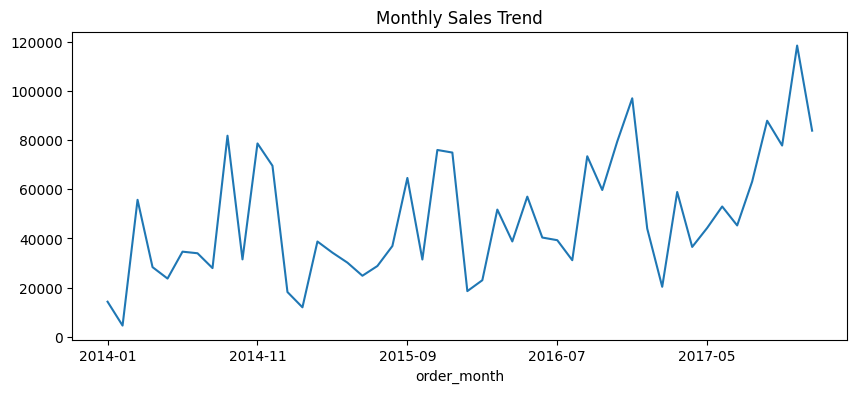

In [ ]:
#Monthly Sales Trend

orders_full["order_month"] = orders_full["order_date"].dt.to_period("M").astype(str)
monthly_sales = orders_full.groupby("order_month")["sales"].sum()


plt.figure(figsize=(10,4))
monthly_sales.plot(kind="line")
plt.title("Monthly Sales Trend")
plt.show()



###Insights


In [ ]:
print("Total Sales :", round(orders_full["sales"].sum(),2))

print("Total Profit : ", round(orders_full["profit"].sum(), 2))

print("Best Category by profit :", orders_full.groupby("category")["profit"].sum().idxmax())

print("Worst Category by profit :", orders_full.groupby("category")["profit"].sum().idxmin())

print("Overall Retune rate %  :",round((orders_full["returned"] == "Yes").mean() * 100, 2))

print("Sales-Discount Correlation : ", round(orders_full["sales"].corr(orders_full["discount"]),2))

print("Profit-Discount Correlation : ", round(orders_full["profit"].corr(orders_full["discount"]),2))


Total Sales : 2297200.86
Total Profit :  286397.02
Best Category by profit : Technology
Worst Category by profit : Furniture
Overall Retune rate %  : 8.0
Sales-Discount Correlation :  -0.03
Profit-Discount Correlation :  -0.22


In [ ]:
Clened_data = pd.read_csv("/content/cleaned/.csv")

In [ ]:
orders["product_name"].str[:25] + '...'

,product_name
0,Bush Somerset Collection ...
1,Hon Deluxe Fabric Upholst...
2,Self-Adhesive Address Lab...
3,Bretford CR4500 Series Sl...
4,Eldon Fold 'N Roll Cart S...
...,...
9989,Ultra Door Pull Handle...
9990,Tenex B1-RE Series Chair ...
9991,Aastra 57i VoIP phone...
9992,It's Hot Message Books wi...


Connecting python script to MS SQL Server
-------------------------


In [ ]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus


In [ ]:
host=r'PRIYEEEEEEEEE\SAKSHIDHOBALE'
database='Retail_Sales_Analysis'

In [ ]:
!pip install pyodbc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.1/350.1 kB 6.5 MB/s eta 0:00:00


In [ ]:
import pyodbc
print(pyodbc.drivers())

['ODBC Driver 17 for SQL Server']


In [ ]:
!curl https://packages.microsoft.com/keys/microsoft.asc | apt-key add -
!curl https://packages.microsoft.com/config/ubuntu/20.04/prod.list -o /etc/apt/sources.list.d/mssql-release.list
!apt-get update
!ACCEPT_EULA=Y apt-get install -y msodbcsql17 unixodbc-dev

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   975  100   975    0     0   4509      0 --:--:-- --:--:-- --:--:--  4534
OK
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    89  100    89    0     0    769      0 --:--:-- --:--:-- --:--:--   773
Get:1 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://packages.microsoft.com/ubuntu/20.04/prod focal InRelease [3,632 B]
Hit:5 http://archive.ubuntu.com/ubuntu noble InRelease
Get:6 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Get:8 http://archive.u

In [ ]:
driver=quote_plus("ODBC Driver 17 for SQL Server")
engine=create_engine(f"mssql+pyodbc://@{host}/{database}"
    f"?driver={driver}&trusted_connection=yes")

In [ ]:
username="sakshi"
password="sakshi@8078"

engine = create_engine(
    f"mssql+pyodbc://{username}:{password}@{host}/{database}?driver={driver}"
)

In [ ]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import pyodbc

print(pyodbc.drivers())   # confirm the exact driver name available

server = r"priyeeeeeeeee\SAKSHIDHOBALE"     # raw string, so \S isn't misread
database = "YourDatabaseName"                # replace with your actual DB name
driver = quote_plus("ODBC Driver 17 for SQL Server")   # use whatever pyodbc.drivers() actually showed

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver={driver}&trusted_connection=yes"
)

orders.to_sql("Orders_data", engine, if_exists="replace", index=False)

['ODBC Driver 17 for SQL Server']


OperationalError: (pyodbc.OperationalError) ('HYT00', '[HYT00] [Microsoft][ODBC Driver 17 for SQL Server]Login timeout expired (0) (SQLDriverConnect)')
(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [ ]:
pd.read_sql("select top 5 * from Orders_data", engine)